# From Circuits to Measurement-Based Quantum Computing

**Objective**
* Convert a simple quantum circuit into a measurement-based quantum computing (MBQC) equivalent using entangled cluster states.

* Understand how measurements on cluster states simulate logic gates.

* Explore the effects of measurement order and basis on computation.

* Simulate “adiabatic-like” evolution via gradual change of parameters in a quantum circuit (since true AQC is not directly supported in Qiskit).



In [ ]:
# !pip install qiskit
# !pip install pylatexenc
# !pip install qiskit_aer
# !pip install networkx

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt
import numpy as np


# Step 1: Build a Reference Quantum Circuit
Create a basic circuit that applies a Hadamard and CNOT (like a Bell state), followed by a Z gate.

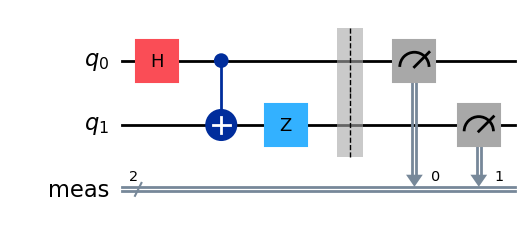

In [ ]:
qc = QuantumCircuit(_)
qc.h(_)
qc.cx(_, _)
qc.z(_)
qc.measure_all()
qc.draw('mpl')


# Step 2: Simulate and Observe

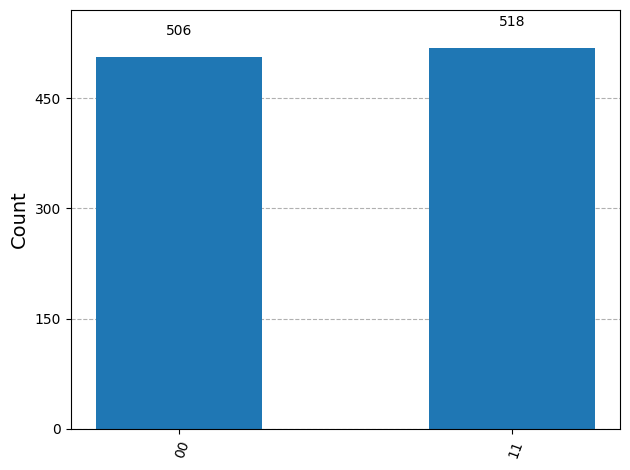

In [ ]:
simulator = AerSimulator()
compiled = transpile(_, _)
result = simulator.run(compiled, shots=1024).result()
counts = result.get_counts()
plot_histogram(_)


# Step 3: Create a Linear Cluster State (MBQC)
Prepare a 3-qubit cluster state. This time, no gates after entanglement — computation happens via measurement.

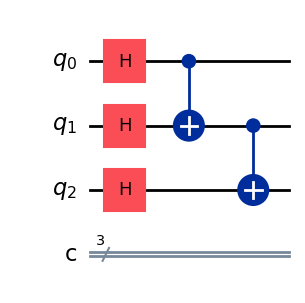

In [ ]:
mbqc = QuantumCircuit(_, _) # Add 3 classical bits
# Initialize all to |+>
for i in range(_):
    mbqc.h(_)

# Entangle linearly: 0-1-2
mbqc.cx(_,_)
mbqc.cx(_,_)

mbqc.draw('mpl')

# Step 4: Perform Measurement-Based Computation
Measure the first and second qubits in rotated basis to simulate computation. Keep the third as output.

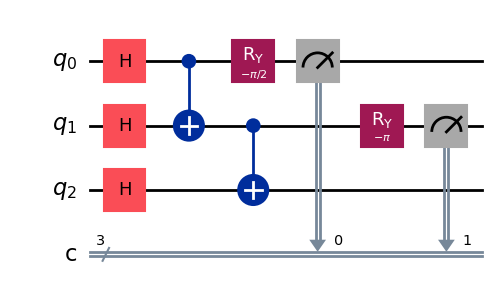

In [ ]:
theta1 = np.pi/4  # measurement angle for qubit 0
theta2 = np.pi/2  # measurement angle for qubit 1

mbqc.ry(-2*_, _)
mbqc.measure(_, _)

mbqc.ry(-2*_, _)
mbqc.measure(_, _)

# Delay measuring qubit 2 to examine final state
mbqc.draw('mpl')

# Step 5: Simulate and Analyze

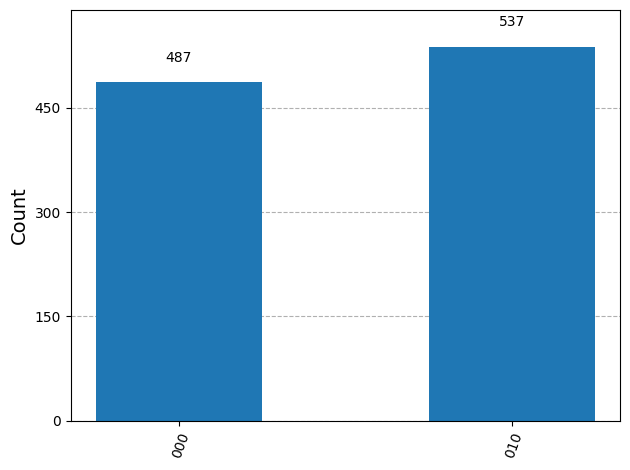

In [ ]:
compiled_mbqc = transpile(_, _)
result_mbqc = simulator.run(_, shots=1024).result()
counts_mbqc = result_mbqc.get_counts()
plot_histogram(_)


# Step 6: Simulated Adiabatic Evolution

Use a parameterized rotation with gradually changing angle to mimic "slow evolution" of Hamiltonian terms.

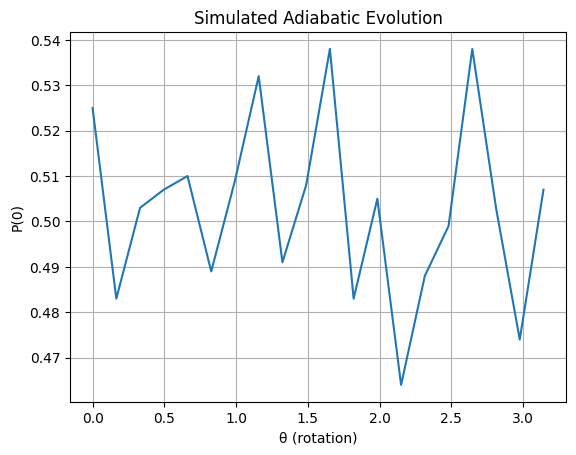

In [ ]:
from qiskit.circuit import Parameter

theta = Parameter("θ")
adiabatic = QuantumCircuit(1)
adiabatic.h(_)
adiabatic.rx(theta, _)
adiabatic.measure_all()

# Simulate evolution from 0 to π
thetas = np.linspace(0, np.pi, 20)
results = []
for t in thetas:
    # Use assign_parameters to bind the parameter
    bound_circuit = adiabatic.assign_parameters({theta: t})
    compiled = transpile(_, _)
    result = simulator.run(compiled, shots=1000).result()
    counts = result.get_counts()
    results.append((_, _))

# Visualize
zero_probs = [counts.get('0', 0)/1000 for _, counts in results]
plt.plot(thetas, zero_probs)
plt.xlabel('θ (rotation)')
plt.ylabel('P(0)')
plt.title('Simulated Adiabatic Evolution')
plt.grid()
plt.show()


# Questions
Before moving on, answer the following questions:
1. In Step 4, try changing the measurement angles. What logical operations do you think you’re performing on the final qubit?

2. Why must we measure qubits in a specific order in MBQC?

3. How would you simulate a logical NOT gate in MBQC using different measurement angles?

4. (Adiabatic) What does the smooth change in the output probability tell you about the system's state evolution?

# Step 7: Visualize the Entanglement Structure (Graph Representation of Cluster State)
Use NetworkX to plot the graph structure of your MBQC cluster state. This gives intuition about how computation flows through entanglement.

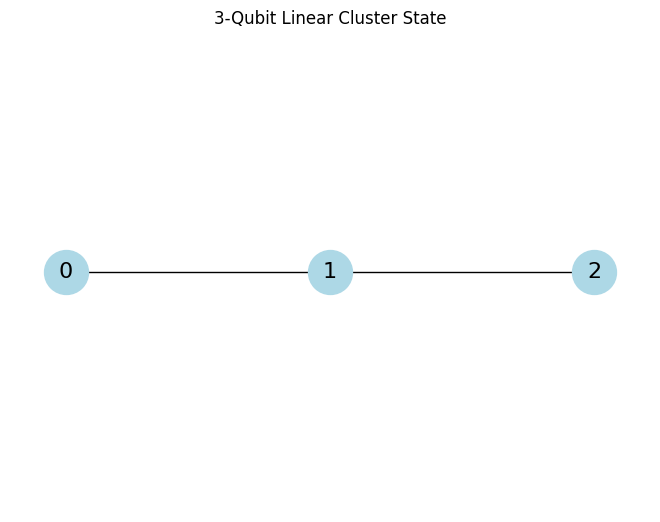

In [ ]:
import networkx as nx

# Create a linear graph for a 3-qubit cluster state
G = nx.Graph()
G.add_edges_from([(0, 1), (1, 2)])

pos = {0: (0, 0), 1: (1, 0), 2: (2, 0)}
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=1000, font_size=16)
plt.title("3-Qubit Linear Cluster State")
plt.show()


# Step 8: Apply MBQC to Implement a Quantum Gate

Let’s simulate an actual gate like an X or Z operation using MBQC.

Task: Apply a Pauli-X gate to a qubit via measurement on a 3-qubit cluster.

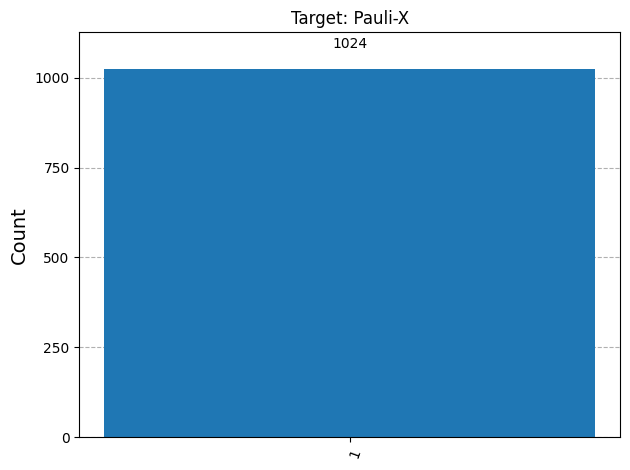

In [ ]:
from qiskit.circuit.library import XGate

# Goal: simulate X using MBQC
target_gate = QuantumCircuit(_)
target_gate.x(_)
target_gate.measure_all()

compiled = transpile(target_gate, simulator)
target_result = simulator.run(compiled, shots=1024).result()
target_counts = target_result.get_counts()
plot_histogram(_, title='Target: Pauli-X')


# Step 9: Compare Circuit Model vs MBQC vs Adiabatic Simulation
Plot a side-by-side bar graph comparing output probabilities for the same logical operation implemented using:

* The circuit model (Step 2)

* MBQC (Step 5 or 8)

* Simulated adiabatic evolution (Step 6)

Are you seeing nothing after plotting? Follow the Debug Challenge!

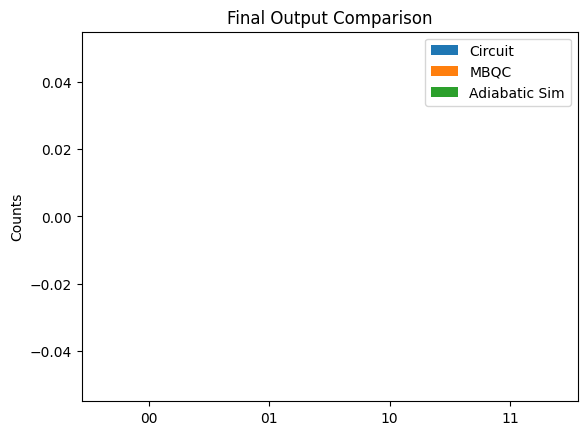

In [ ]:
labels = ['00', '01', '10', '11']
circuit_vals = [counts.get(l, 0) for l in labels]
mbqc_vals = [counts_mbqc.get(l, 0) for l in labels]
adiabatic_vals = [results[-1][1].get(l, 0) if l in results[-1][1] else 0 for l in labels]

x = np.arange(len(labels))
width = 0.25

plt.bar(x - width, circuit_vals, width, label='Circuit')
plt.bar(x, mbqc_vals, width, label='MBQC')
plt.bar(x + width, adiabatic_vals, width, label='Adiabatic Sim')

plt.xticks(x, labels)
plt.ylabel('Counts')
plt.title('Final Output Comparison')
plt.legend()
plt.show() ####### Are you seeing nothing? follow the debug challenge!


# Debug Challenge:
The comparison plot in Step 9 is either blank or missing bars for the circuit model. Why?

You’ve already run and plotted the results from your circuit in Step 2 and your MBQC circuit in Step 5. But in Step 9, when we build a side-by-side comparison, we’re trying to plot counts for four specific classical bitstrings: '00', '01', '10', and '11'.

Let’s take a look at this snippet again:

``labels = ['00', '01', '10', '11']``

``circuit_vals = [counts.get(l, 0) for l in labels]``

Now here’s the tricky part:

The ``counts`` dictionary here (from your 2-qubit circuit) might not actually be called ``counts``. Or even if it is, the variable might be redefined later in your code (e.g., overwritten by the MBQC results). So what you're actually accessing could be wrong or outdated.

Also, if the original 2-qubit circuit didn’t have proper classical registers or ``measure_all()``, the backend might not have returned counts for two classical bits—maybe it returned just '0' or '1'.

**Here’s what you should do to fix the plot:**

1. Double-check variable names:
Make sure the results from the circuit model in Step 2 are saved into a clearly named variable like:

`` result_circuit = simulator.run(compiled, shots=1024).result()``

``counts_circuit = result_circuit.get_counts() ``

2. Print the actual keys:
Before the plotting step, print the keys from each ``counts_*`` dictionary to see what bitstrings you got:
`` print(counts_circuit)``

``print(counts_mbqc)``

``print(results[-1][1])``

You may notice something unexpected—like '0', '1', or bitstrings in reverse order.

3. Check how many classical bits are in the measurement:
If you only measured one qubit, you won’t get results for '00', '01', etc. You need:

``qc.measure_all()``

or explicit measurements of both qubits to two classical bits:

``qc.measure(0, 0)``

``qc.measure(1, 1)``

Fix the plot by adjusting your expectations:
If your circuit only measured one qubit, you should only expect '0' and '1', not 2-bit strings like '10'.

# Question:
How does decoherence affect each model differently? (Start with the defining coherence and decoherence first!)